In [1]:
import pandas as pd

# Basic
df = pd.read_csv("/scratch/prj0000000262/Sanwa/2025.12.16Cam6_Snap1_Latch_mapped_output_YX.csv")

print(df.head())
print(df.shape)


   Mould  Cavity  production_cycle  injection_time  switchover_position  \
0      2       5             36.76            1.69                 9.99   
1      2       6             36.76            1.69                 9.99   
2      2       7             36.76            1.69                 9.99   
3      2       8             36.76            1.69                 9.99   
4      2       5             36.77            1.69                 9.99   

   max_injection_pressure  switchover_pressure  end_of_packing_stroke  \
0                   158.6                 1222                   3.24   
1                   158.6                 1222                   3.24   
2                   158.6                 1222                   3.24   
3                   158.6                 1222                   3.24   
4                   157.3                 1216                   3.22   

   plastification_time  nozzle_temperature  barrel_front_temperature  \
0                 8.39               2

In [2]:
import numpy as np

cols = [
    "Mould",
    "Cavity",
    "barrel_front_temperature",
    "barrel_rear_temperature",
    "max_injection_pressure",
    "switchover_position",
    "injection_time",
]

X = df.loc[:, cols].to_numpy()   # or df[cols].to_numpy()

print(X.shape)   # should be (508, 7) if you have 508 rows
print(type(X))   # <class 'numpy.ndarray'>


(508, 7)
<class 'numpy.ndarray'>


In [3]:
# If column name is the integer 14
y = df['ROI_16'].to_numpy()

print(y.shape)   # (508,)
print(type(y))   # numpy.ndarray


(508,)
<class 'numpy.ndarray'>


In [11]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def train_nn_predict(X, y, test_size=0.2, random_state=42, epochs=200, batch_size=64):
    # ---- 0) Ensure numpy arrays ----
    X = np.asarray(X)
    y = np.asarray(y)

    # If y is shape (n,1), flatten for classification detection
    y_flat = y.reshape(-1) if (y.ndim == 2 and y.shape[1] == 1) else y

    # ---- 1) Infer task type ----
    # Heuristic: classification if y is int-like and has "few" unique values
    is_int_like = np.issubdtype(y_flat.dtype, np.integer) or np.allclose(y_flat, np.round(y_flat))
    unique = np.unique(y_flat)
    n_unique = unique.shape[0]

    is_classification = bool(is_int_like and n_unique <= 50)  # tweak if you want

    # ---- 2) Train/val split ----
    stratify = y_flat if (is_classification and y_flat.ndim == 1) else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )

    # ---- 3) Scale features (important for MLPs) ----
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # ---- 4) Build model ----
    tf.keras.utils.set_random_seed(random_state)

    model = keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
    ])

    if is_classification:
        # ---- Classification heads ----
        if n_unique == 2:
            # Binary classification (y should be 0/1)
            model.add(layers.Dense(1, activation="sigmoid"))
            loss = "binary_crossentropy"
            metrics = ["accuracy"]
        else:
            # Multiclass classification (y should be class indices: 0..K-1)
            model.add(layers.Dense(n_unique, activation="softmax"))
            loss = "sparse_categorical_crossentropy"
            metrics = ["accuracy"]

        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss, metrics=metrics)

    else:
        # ---- Regression head ----
        # Supports y as shape (n,) or (n, k) for multi-output
        out_dim = 1 if y_train.ndim == 1 else y_train.shape[1]
        model.add(layers.Dense(out_dim))
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=[keras.metrics.RootMeanSquaredError()])

    # ---- 5) Train ----
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    ]

    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    # ---- 6) Predict + Evaluate ----
    y_pred = model.predict(X_test_s)

    if is_classification:
        if n_unique == 2:
            y_pred_label = (y_pred.reshape(-1) >= 0.5).astype(int)
            y_true = y_test.reshape(-1)
        else:
            y_pred_label = np.argmax(y_pred, axis=1)
            y_true = y_test.reshape(-1)

        acc = accuracy_score(y_true, y_pred_label)
        print(f"Task: classification | classes={n_unique} | test accuracy={acc:.4f}")

    else:
        # For regression, flatten if single-output
        if y_pred.shape[1] == 1:
            y_pred_ = y_pred.reshape(-1)
            y_true_ = y_test.reshape(-1)
            rmse = np.sqrt(mean_squared_error(y_true_, y_pred_))
            r2 = r2_score(y_true_, y_pred_)
            print(f"Task: regression | test RMSE={rmse:.4f} | R2={r2:.4f}")
        else:
            # Multi-output regression: report average RMSE across outputs
            rmses = []
            for j in range(y_pred.shape[1]):
                rmse_j = np.sqrt(mean_squared_error(y_test[:, j], y_pred[:, j]))
                rmses.append(rmse_j)
            print(f"Task: regression (multi-output) | mean RMSE={np.mean(rmses):.4f}")

    return model, scaler, history, y_pred, y_test




In [12]:
model, scaler, history, y_pred, y_test = train_nn_predict(X, y)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.8563 - root_mean_squared_error: 1.6901 - val_loss: 1.6815 - val_root_mean_squared_error: 1.2967
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4526 - root_mean_squared_error: 1.2052 - val_loss: 0.7786 - val_root_mean_squared_error: 0.8824
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6678 - root_mean_squared_error: 0.8172 - val_loss: 0.3674 - val_root_mean_squared_error: 0.6062
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3430 - root_mean_squared_error: 0.5857 - val_loss: 0.2932 - val_root_mean_squared_error: 0.5415
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2791 - root_mean_squared_error: 0.5283 - val_loss: 0.3192 - val_root_mean_squared_error: 0.5650
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3196 - root_mean_squared_error: 0.5653 - val_loss: 0.2398 - val_root_mean_squared_error: 0.4897
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2273 - roo

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0499 - root_mean_squared_error: 0.2233 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0823
Epoch 88/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0582 - root_mean_squared_error: 0.2413 - val_loss: 0.0106 - val_root_mean_squared_error: 0.1028
Epoch 89/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0551 - root_mean_squared_error: 0.2347 - val_loss: 0.0061 - val_root_mean_squared_error: 0.0783
Epoch 90/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0602 - root_mean_squared_error: 0.2454 - val_loss: 0.0061 - val_root_mean_squared_error: 0.0783
Epoch 91/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0522 - root_mean_squared_error: 0.2285 - val_loss: 0.0116 - val_root_mean_squared_error: 0.1078
Epoch 92/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0615 - root_mean_squared_error: 0.2480 - val_loss: 0.0096 - val_root_mean_squared_error: 0.0979
Epoch 93/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0509 - root_mean_

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def plot_true_vs_pred_regression(y_test, y_pred, title="Test: True vs Pred"):
    y_true = np.asarray(y_test).reshape(-1)
    y_hat  = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    r2 = r2_score(y_true, y_hat)

    # True vs Pred
    plt.figure()
    plt.scatter(y_true, y_hat)
    mn = min(y_true.min(), y_hat.min())
    mx = max(y_true.max(), y_hat.max())
    plt.plot([mn, mx], [mn, mx])  # y=x reference line
    plt.xlabel("True (y_test)")
    plt.ylabel("Predicted (y_pred)")
    plt.title(f"{title}\nRMSE={rmse:.4f}, R2={r2:.4f}")
    plt.show()

    # Residuals
    plt.figure()
    plt.scatter(y_hat, (y_true - y_hat))
    plt.axhline(0)
    plt.xlabel("Predicted (y_pred)")
    plt.ylabel("Residual (y_true - y_pred)")
    plt.title("Residual plot (test)")
    plt.show()


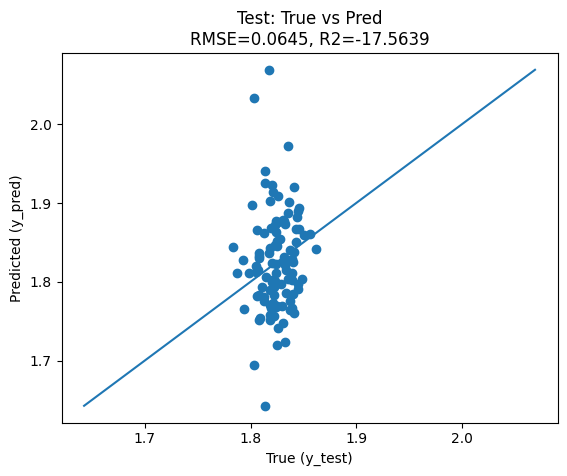

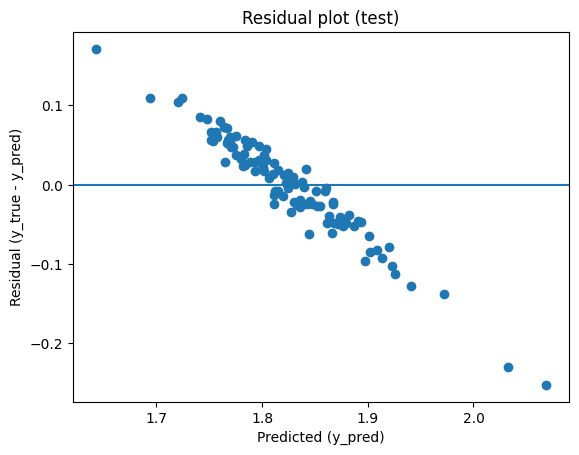

In [14]:
plot_true_vs_pred_regression(y_test, y_pred)
